<a href="https://colab.research.google.com/github/nabeelnazeer/Reggresion-anaylsis/blob/main/logisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data[:100, :2]  # Use only the first two features for visualization
y = iris.target[:100]     # Only the first 100 samples (Setosa vs. Versicolor)

# Convert target to binary: 1 if Setosa, 0 if Versicolor
y = (y == 0).astype(int)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [4]:
def compute_cost(y, y_pred):
    m = len(y)
    cost = -1/m * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return cost


In [5]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)  # Initialize weights

    for _ in range(epochs):
        z = np.dot(X, theta)
        y_pred = sigmoid(z)

        # Compute the cost
        cost = compute_cost(y, y_pred)

        # Compute the gradient
        gradient = np.dot(X.T, (y_pred - y)) / m

        # Update weights
        theta -= learning_rate * gradient

    return theta


In [6]:
# Add an intercept term to the features
X_train_intercept = np.hstack((np.ones((X_train.shape[0], 1)), X_train))

# Train the model
theta = gradient_descent(X_train_intercept, y_train, learning_rate=0.1, epochs=1000)


In [7]:
def predict(X, theta):
    X_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
    probabilities = sigmoid(np.dot(X_intercept, theta))
    return (probabilities >= 0.5).astype(int)

# Make predictions
y_pred = predict(X_test, theta)


In [8]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Calculate accuracy
acc = accuracy(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')


Accuracy: 1.0000


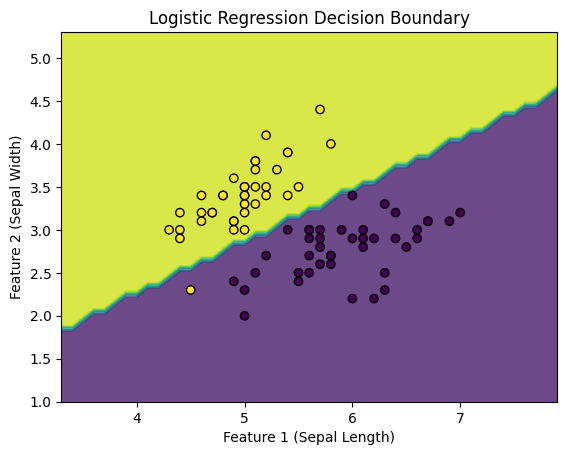

In [9]:
def plot_decision_boundary(X, y, theta):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = predict(np.c_[xx.ravel(), yy.ravel()], theta)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Feature 1 (Sepal Length)')
    plt.ylabel('Feature 2 (Sepal Width)')
    plt.title('Logistic Regression Decision Boundary')
    plt.show()

# Plot decision boundary
plot_decision_boundary(X_train, y_train, theta)
